# Day 33 - Customer Churn Preprocessing

## 학습 주제

실제 머신러닝 데이터에 존재할 수 있는 결측값,
범주형 변수와 서로 다른 수치 척도를 처리하는
기본 전처리 과정을 학습한다.

이번 실습에서는 다음 내용을 확인한다.

- Missing Values
- SimpleImputer
- Categorical Features
- One-Hot Encoding
- StandardScaler
- fit / transform / fit_transform
- Data Leakage

## 분석 질문

1. 결측값이 있는 데이터를 모델에 어떻게 입력할 수 있는가?
2. 범주형 문자열 Feature를 어떻게 숫자 형태로 바꿀 수 있는가?
3. 단위가 다른 수치형 Feature를 왜 표준화하는가?
4. 전처리 규칙을 왜 Train 데이터에서만 학습해야 하는가?
5. 전처리 후 데이터가 Logistic Regression에 정상적으로 입력되는가?

## 데이터

이번 실습에서는 머신러닝 전처리 학습을 위해 생성한
1,000명의 가상 고객 데이터를 사용한다.

수치형 Feature와 범주형 Feature가 함께 존재하며,
일부 Feature에는 결측값이 포함되어 있다.

Target:

- 0: 향후 30일 유지
- 1: 향후 30일 이탈

이 데이터는 학습용 가상 데이터이며
실제 기업이나 고객 행동을 의미하지 않는다.

In [1]:
# 라이브러리
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
# Path 설정
project_root = Path.cwd().parent

input_path = (
    project_root
    / "data"
    / "raw"
    / "day33_customer_churn_preprocessing.csv"
)

output_dir = (
    project_root
    / "outputs"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(
    input_path
)

d:\Study\Projects\00_foundation_review\data\raw\day33_customer_churn_preprocessing.csv


In [3]:
# 데이터 불러오기
df = pd.read_csv(
    input_path
)

print(
    df.head()
)

print(
    df.shape
)

   customer_id  login_days_30d  order_count_90d  membership_months  \
0            1               2              6.0                 49   
1            2              23              2.0                 33   
2            3              20              2.0                 56   
3            4              13              2.0                 45   
4            5              13              2.0                 57   

   days_since_last_login  monthly_fee  support_tickets_90d contract_type  \
0                     31      56137.0                  2.0        annual   
1                     40      68460.0                  2.0       monthly   
2                     15      54803.0                  1.0       monthly   
3                     46      50251.0                  NaN           NaN   
4                     38      51238.0                  1.0      two_year   

  region device_type  next_30d_churn  
0  other      mobile               0  
1  seoul      mobile               1  
2  se

In [4]:
# 데이터 구조보기
print(
    df.dtypes
)

print(
    df.isna().sum()
)

customer_id                int64
login_days_30d             int64
order_count_90d          float64
membership_months          int64
days_since_last_login      int64
monthly_fee              float64
support_tickets_90d      float64
contract_type                str
region                       str
device_type                  str
next_30d_churn             int64
dtype: object
customer_id               0
login_days_30d            0
order_count_90d          43
membership_months         0
days_since_last_login     0
monthly_fee              58
support_tickets_90d      47
contract_type            38
region                   38
device_type               0
next_30d_churn            0
dtype: int64


In [5]:
# 결측치 정리
missing_summary = (
    df.isna().sum()
)

missing_summary_df = (
    missing_summary
    .rename_axis(
        "feature"
    )
    .reset_index(
        name = "missing_count"
    )
)

print(
    missing_summary_df
)

                  feature  missing_count
0             customer_id              0
1          login_days_30d              0
2         order_count_90d             43
3       membership_months              0
4   days_since_last_login              0
5             monthly_fee             58
6     support_tickets_90d             47
7           contract_type             38
8                  region             38
9             device_type              0
10         next_30d_churn              0


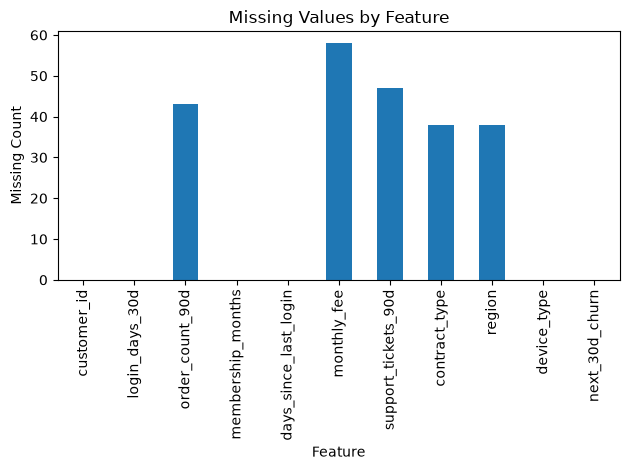

In [6]:
# 결측치 그래프
missing_figure_path = (
    output_dir
    / "customer_churn_preprocessing_missing_values.png"
)

missing_summary_df.plot.bar(
    x = "feature",
    y = "missing_count",
    legend = False
)

plt.title(
    "Missing Values by Feature"
)

plt.xlabel(
    "Feature"
)

plt.ylabel(
    "Missing Count"
)

plt.tight_layout()

plt.savefig(
    missing_figure_path,
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

In [ ]:
# Feature / Target 정의
numeric_features = [
    "login_days_30d",
    "order_count_90d",
    "membership_months",
    "days_since_last_login",
    "monthly_fee",
    "support_tickets_90d"
]

categorical_features = [
    "contract_type",
    "region",
    "device_type"
]

features = (
    numeric_features
    + categorical_features
)

X = df[
    features
]

y = df[
    "next_30d_churn"
]

     login_days_30d  order_count_90d  membership_months  \
0                 2              6.0                 49   
1                23              2.0                 33   
2                20              2.0                 56   
3                13              2.0                 45   
4                13              2.0                 57   
..              ...              ...                ...   
995              19              5.0                 26   
996              16              3.0                 41   
997              11              5.0                 45   
998              29              2.0                 25   
999              15              3.0                 16   

     days_since_last_login  monthly_fee  support_tickets_90d contract_type  \
0                       31      56137.0                  2.0        annual   
1                       40      68460.0                  2.0       monthly   
2                       15      54803.0                  

## Train / Test Split

전처리를 수행하기 전에 먼저 Train과 Test를 분리한다.

결측값 대체값, One-Hot Encoding 범주와
StandardScaler의 평균·표준편차는
Train 데이터에서만 학습한다.

Test 데이터에는 Train에서 학습한 규칙만 적용한다.

In [8]:
# Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(
    X_train.shape
)

print(
    X_test.shape
)

print(
    y_train.value_counts()
)

print(
    y_test.value_counts()
)

(750, 9)
(250, 9)
next_30d_churn
0    517
1    233
Name: count, dtype: int64
next_30d_churn
0    172
1     78
Name: count, dtype: int64


## Numeric Missing Value Imputation

수치형 Feature의 결측값은
Train 데이터의 중앙값으로 대체한다.

Train에서는 fit_transform()을 사용하여
중앙값을 학습하면서 동시에 데이터를 변환한다.

Test에서는 Train에서 학습한 중앙값을 사용해야 하므로
transform()만 사용한다.

In [10]:
numeric_imputer = SimpleImputer(
    strategy = "median"
)

X_train_numeric_imputed = numeric_imputer.fit_transform(
    X_train[
        numeric_features
    ]
)

X_test_numeric_imputed = numeric_imputer.transform(
    X_test[
        numeric_features
    ]
)

print(
    X_train_numeric_imputed.shape
)

print(
    X_test_numeric_imputed.shape
)

(750, 6)
(250, 6)


## Standard Scaling

수치형 Feature는 서로 단위와 범위가 다르다.

StandardScaler를 이용하여
Train 데이터의 평균과 표준편차를 기준으로 표준화한다.

StandardScaler는 데이터의 척도를 변경하지만
데이터를 정규분포로 바꾸는 것은 아니다.

In [11]:
scaler = StandardScaler()

X_train_numeric_scaled = scaler.fit_transform(
    X_train_numeric_imputed
)

X_test_numeric_scaled = scaler.transform(
    X_test_numeric_imputed
)

print(
    X_train_numeric_scaled.shape
)

print(
    X_test_numeric_scaled.shape
)

(750, 6)
(250, 6)


In [13]:
# scaling 확인
scale_check_df = pd.DataFrame(
    {
        "feature" : numeric_features,
        "scaled_train_mean" : X_train_numeric_scaled.mean(
            axis = 0
        ),
        "scaled_train_std" : X_test_numeric_scaled.std(
            axis = 0
        )
    }
)

print(
    scale_check_df
)

                 feature  scaled_train_mean  scaled_train_std
0         login_days_30d       6.631732e-17          0.997832
1        order_count_90d      -7.342275e-17          1.034734
2      membership_months       9.473903e-17          1.034713
3  days_since_last_login       5.210647e-17          0.986086
4            monthly_fee      -2.226367e-16          0.958695
5    support_tickets_90d       6.276461e-17          0.948684


## Categorical Missing Value Imputation

범주형 Feature에는 중앙값이 존재하지 않는다.

따라서 Train 데이터에서 가장 자주 나타난 범주를 이용하여
결측값을 대체한다.

Test 데이터에서도 Train에서 학습한 동일한 값을 사용한다.

In [15]:
categorical_imputer = SimpleImputer(
    strategy = "most_frequent"
)

X_train_categorical_imputed = categorical_imputer.fit_transform(
    X_train[
        categorical_features
    ]
)

X_test_categorical_imputed = categorical_imputer.transform(
    X_test[
        categorical_features
    ]
)

print(
    X_train_categorical_imputed[:5]
)

[['monthly' 'gyeonggi' 'tablet']
 ['two_year' 'gyeonggi' 'tablet']
 ['annual' 'other' 'desktop']
 ['two_year' 'seoul' 'mobile']
 ['annual' 'other' 'mobile']]


In [17]:
# One-Hot Encoding
encoder = OneHotEncoder(
    handle_unknown = "ignore",
    sparse_output = False
)

X_train_categorical_encoded = encoder.fit_transform(
    X_train_categorical_imputed
)

X_test_categorical_encoded = encoder.transform(
    X_test_categorical_imputed
)

print(
    X_train_categorical_encoded.shape
)

print(
    X_test_categorical_encoded.shape
)

(750, 9)
(250, 9)


## Combine Preprocessed Features

수치형 Feature와 범주형 Feature는
서로 다른 전처리를 거쳤다.

모델에는 하나의 Feature 행렬을 입력해야 하므로
두 배열을 열 방향으로 결합한다.

In [19]:
# 수치형 + 범주형
X_train_preprocessed = np.hstack(
    [
        X_train_numeric_scaled,
        X_train_categorical_encoded
    ]
)

X_test_preprocessed = np.hstack(
    [
        X_test_numeric_scaled,
        X_test_categorical_encoded
    ]
)

print(
    X_train_preprocessed.shape
)

print(
    X_test_preprocessed.shape
)

(750, 15)
(250, 15)


In [20]:
# 전처리 후 모델 학습
model = LogisticRegression()

model.fit(
    X_train_preprocessed,
    y_train
)

prediction = model.predict(
    X_test_preprocessed
)

In [21]:
accuracy = accuracy_score(
    y_test,
    prediction
)

precision = precision_score(
    y_test,
    prediction
)

recall = recall_score(
    y_test,
    prediction
)

f1 = f1_score(
    y_test,
    prediction
)

print(
    f"Accuracy: {accuracy:.3f}"
)

print(
    f"Precision: {precision:.3f}"
)

print(
    f"Recall: {recall:.3f}"
)

print(
    f"F1: {f1:.3f}"
)

Accuracy: 0.764
Precision: 0.661
Recall: 0.500
F1: 0.569


In [22]:
# confusion matrix
confusion = confusion_matrix(
    y_test,
    prediction
)

confusion_df = pd.DataFrame(
    confusion,
    index=[
        "actual_0",
        "actual_1",
    ],
    columns=[
        "predicted_0",
        "predicted_1",
    ]
)

print(
    confusion_df
)

          predicted_0  predicted_1
actual_0          152           20
actual_1           39           39


In [23]:
metrics_df = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "precision",
            "recall",
            "f1",
        ],
        "score": [
            accuracy,
            precision,
            recall,
            f1,
        ],
    }
)

prediction_df = pd.DataFrame(
    {
        "customer_id": df.loc[
            X_test.index,
            "customer_id"
        ],
        "actual_churn": y_test,
        "predicted_churn": prediction,
    }
)

print(
    metrics_df
)

print(
    prediction_df.head()
)

      metric     score
0   accuracy  0.764000
1  precision  0.661017
2     recall  0.500000
3         f1  0.569343
     customer_id  actual_churn  predicted_churn
828          829             1                0
814          815             0                1
149          150             1                0
205          206             1                1
148          149             0                0


In [24]:
missing_summary_path = (
    output_dir
    / "customer_churn_preprocessing_missing_summary.csv"
)

scale_check_path = (
    output_dir
    / "customer_churn_preprocessing_scale_check.csv"
)

metrics_path = (
    output_dir
    / "customer_churn_preprocessed_logistic_metrics.csv"
)

confusion_path = (
    output_dir
    / "customer_churn_preprocessed_logistic_confusion_matrix.csv"
)

prediction_path = (
    output_dir
    / "customer_churn_preprocessed_predictions.csv"
)

missing_summary_df.to_csv(
    missing_summary_path,
    index=False
)

scale_check_df.to_csv(
    scale_check_path,
    index=False
)

metrics_df.to_csv(
    metrics_path,
    index=False
)

confusion_df.to_csv(
    confusion_path
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

## 최종 해석

### 데이터 품질

- 전체 고객 수: 1000
- 결측 Feature 수: 5 
- 주요 결측 개수: 

feature             missing_count
order_count_90d     43
monthly_fee         58
support_tickets_90d 47
contract_type       38
region              38

### 전처리 결과

- Train 고객 수: 750
- Test 고객 수: 250
- 전처리 후 Feature 수: 15

수치형 Feature는 Train 데이터의 중앙값으로 결측값을 대체한 뒤
StandardScaler를 적용했다.

범주형 Feature는 Train 데이터의 최빈값으로 결측값을 대체하고
One-Hot Encoding을 적용했다.

모든 전처리 규칙은 Train 데이터에서만 학습했으며
Test 데이터에는 Train에서 학습한 규칙만 적용했다.

### 모델 결과

- Accuracy: 0.764
- Precision: 0.661
- Recall: 0.500
- F1 Score: 0.569

### 배운 점

머신러닝 모델 학습 이전에
결측값, 범주형 Feature와 Feature 척도를 처리해야 할 수 있다.

전처리는 단순 데이터 정리가 아니라
모델 학습 과정의 일부이며,
Test 데이터의 정보를 이용해 전처리 규칙을 학습하면
데이터 누수가 발생할 수 있다.

### 한계

이번 데이터는 머신러닝 전처리 학습 목적으로 생성한 가상 데이터다.

결측값을 중앙값이나 최빈값으로 대체하는 전략이
모든 실제 데이터에 최적인 것은 아니다.

실제 프로젝트에서는 결측 발생 원인과 비율을 먼저 확인하고
업무 의미에 맞는 처리 방법을 선택해야 한다.

이번 실습은 전처리 과정을 직접 이해하기 위해
각 단계를 수동으로 연결했다.

이후 Pipeline을 이용하여
전처리와 모델 학습을 하나의 재현 가능한 과정으로 연결할 예정이다.